
--- Analisando Modelo: Random Forest ---


[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerator
[16:21:08] DEPRECATION WARNING: please use MorganGenerat

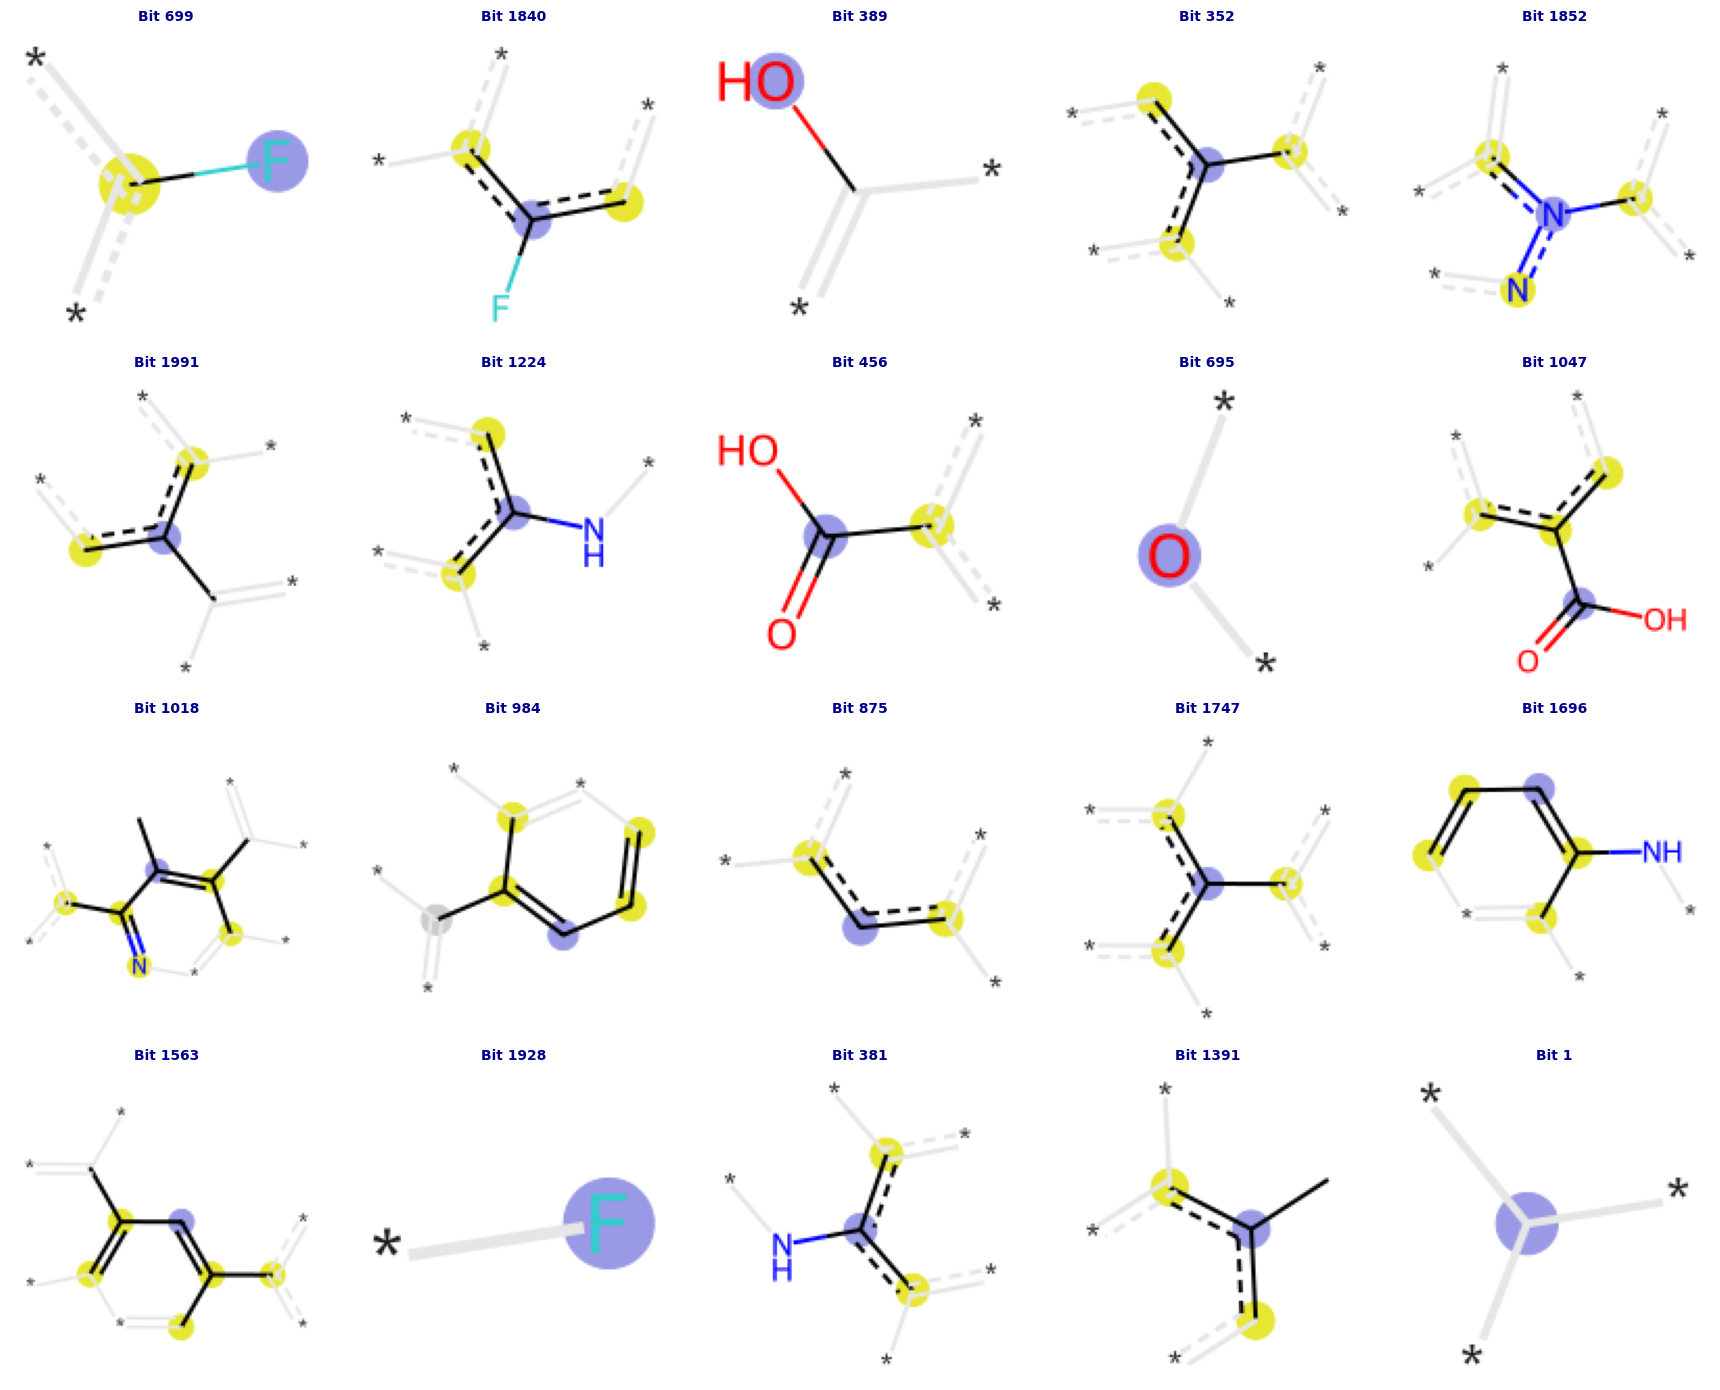


--- Analisando Modelo: XGBoost ---


[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerator
[16:21:09] DEPRECATION WARNING: please use MorganGenerat

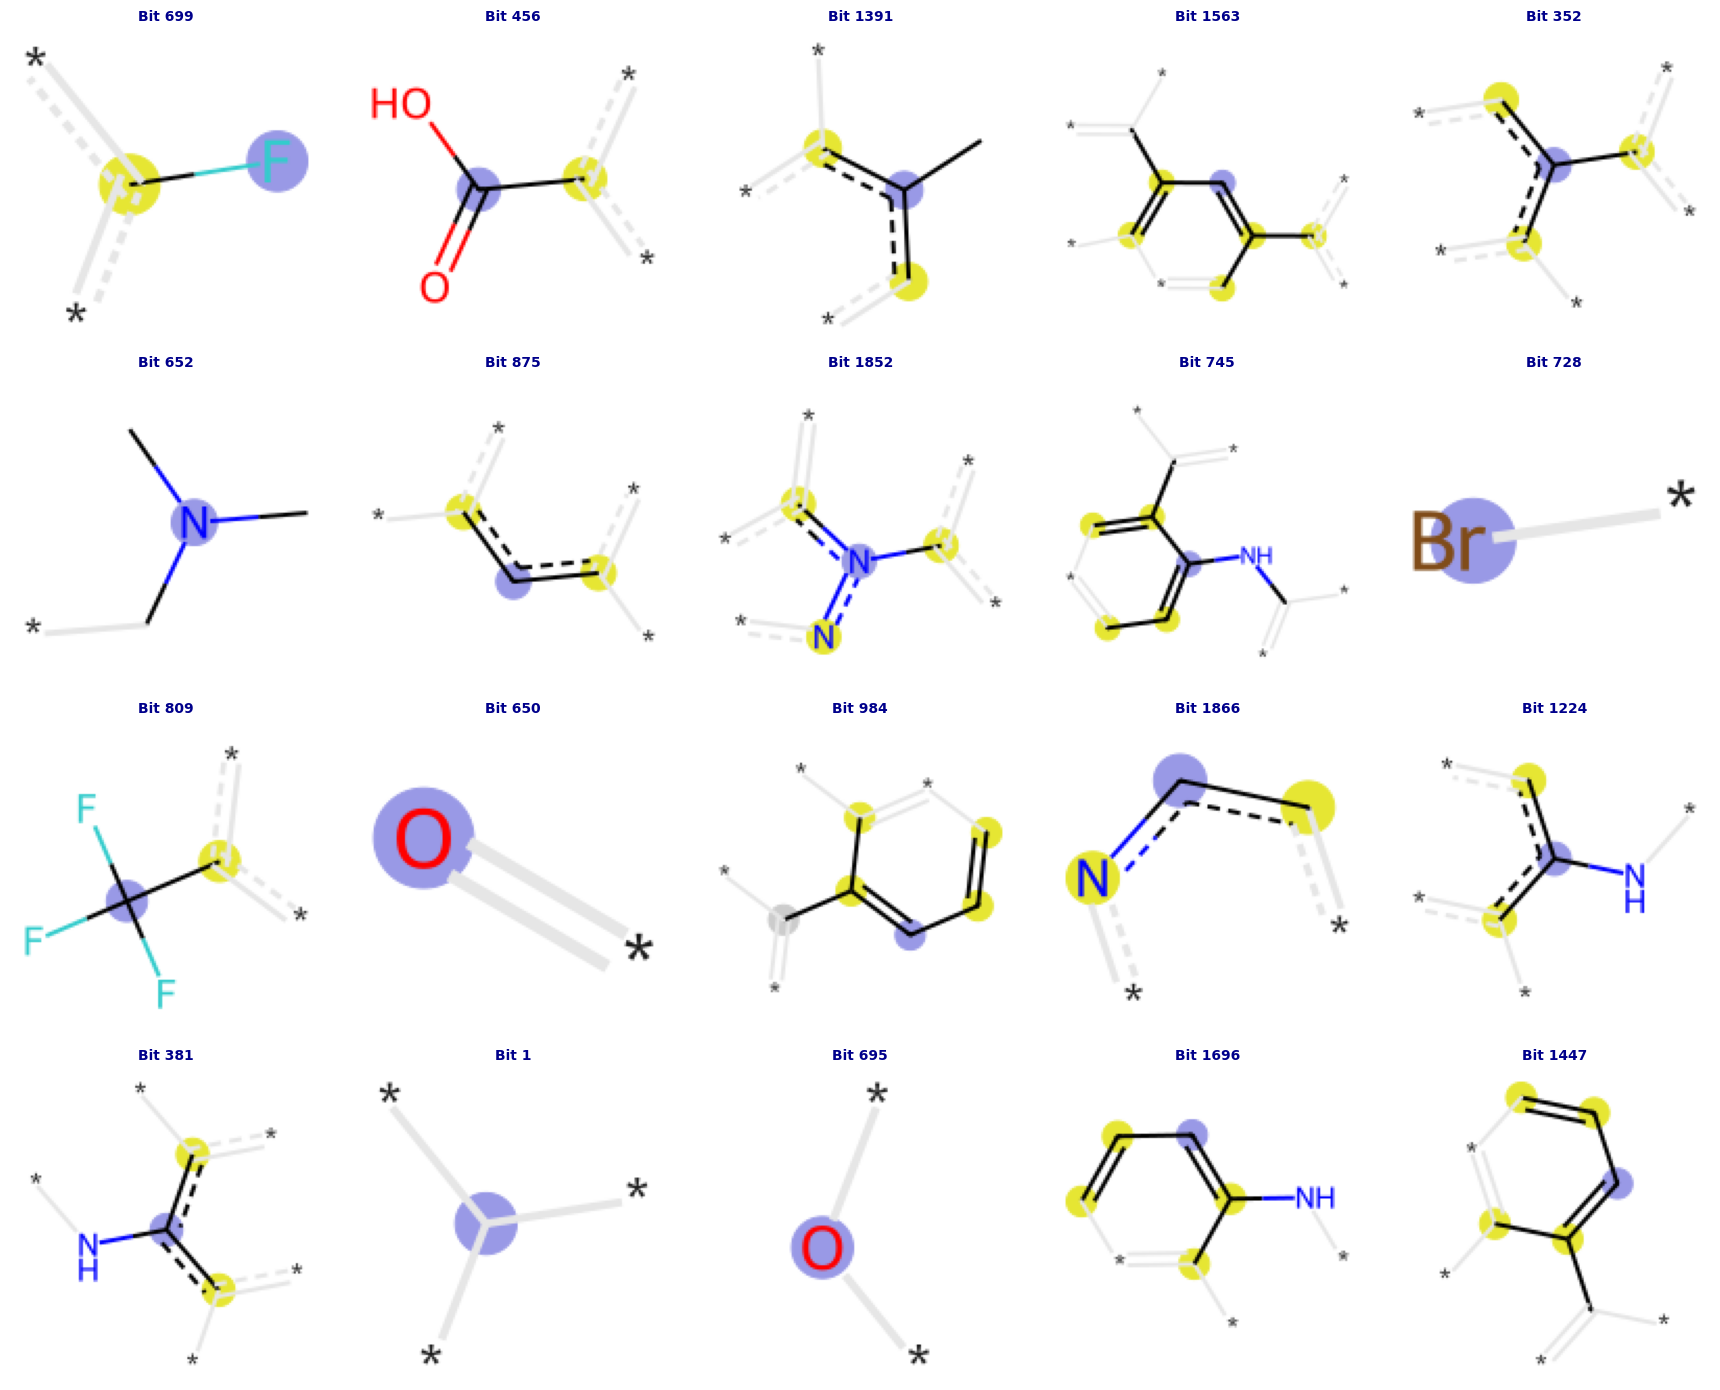

,Bit,SMILES_Fragment,Model
0,699,cF,Random Forest
1,1840,cc(c)F,Random Forest
2,389,CO,Random Forest
3,352,cc(c)-c,Random Forest
4,1852,cn(-c)n,Random Forest
5,1991,cc(c)C,Random Forest
6,1224,cc(c)N,Random Forest
7,456,cC(=O)O,Random Forest
8,695,,Random Forest
9,1047,cc(c)C(=O)O,Random Forest


In [1]:
import pandas as pd
import numpy as np
import joblib
import math
import sys
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem, Draw, rdDepictor
from types import ModuleType

# =============================================================================
# 0. RECONSTRUÇÃO ROBUSTA DA HIERARQUIA (CATCH-ALL)
# =============================================================================

class Pipeline(object):
    def __init__(self, *args, **kwargs): self.steps = []
    def __setstate__(self, state): self.__dict__.update(state)

class DummyTransformer(object):
    def __init__(self, *args, **kwargs): pass
    def __setstate__(self, state): self.__dict__.update(state)

def _fake_func(*args, **kwargs): return None

# Criar os módulos
def create_mock_module(full_name):
    parts = full_name.split('.')
    parent = None
    for i in range(len(parts)):
        mod_name = ".".join(parts[:i+1])
        if mod_name not in sys.modules:
            m = ModuleType(parts[i])
            m.__path__ = []
            sys.modules[mod_name] = m
        if parent:
            setattr(parent, parts[i], sys.modules[mod_name])
        parent = sys.modules[mod_name]
    return sys.modules[full_name]

pycaret_mod = create_mock_module("pycaret.internal.pipeline")
trans_mod = create_mock_module("pycaret.internal.preprocess.transformers")

# Configurar Aliases
sys.modules["transformers"] = trans_mod 
sys.modules["pipeline"] = pycaret_mod 

# Injetar classes e as funções utilitárias que o pickle exige
pycaret_mod.Pipeline = Pipeline
pycaret_mod._fit_one = _fake_func
pycaret_mod._transform_one = _fake_func
pycaret_mod._full_transform = _fake_func # Resolve o erro atual
trans_mod.TransformerWrapper = DummyTransformer
trans_mod.RemoveMulticollinearity = DummyTransformer
trans_mod.FixImbalancer = DummyTransformer

# =============================================================================
# 1. CONFIGURAÇÃO DE CAMINHOS
# =============================================================================
path_csv = r'C:\Users\sabri\repositorios\Identification-of-Potent-HsDHODH-Inhibitors-via-Integrated-Computational-Pipeline\fp-gen\ECFP\HsDHODH-curated_ecfp_diam4_2048bits.csv'
path_rf = r'C:\Users\sabri\repositorios\Identification-of-Potent-HsDHODH-Inhibitors-via-Integrated-Computational-Pipeline\models\HsDHODH_ECFP_diam4_1845bits_RandomForest_tunned.pkl'
path_xgb = r'C:\Users\sabri\repositorios\Identification-of-Potent-HsDHODH-Inhibitors-via-Integrated-Computational-Pipeline\models\HsDHODH_ECFP_diam4_1845bits_XGBoost_tunned.pkl'

bits_rf = [699, 1840, 389, 352, 1852, 1991, 1224, 456, 695, 1047, 1018, 984, 875, 1747, 1696, 1563, 1928, 381, 1391, 1]
bits_xgb = [699, 456, 1391, 1563, 352, 652, 875, 1852, 745, 728, 809, 650, 984, 1866, 1224, 381, 1, 695, 1696, 1447]

# =============================================================================
# 2. FUNÇÕES DE PROCESSAMENTO QUÍMICO
# =============================================================================

def get_fragment_data(mols, target_bits):
    found_data = {}
    needed = set(target_bits)
    for mol in mols:
        if not mol or not needed: break
        bi = {}
        _ = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048, bitInfo=bi)
        for bit in list(needed):
            if bit in bi:
                atom_idx, rad = bi[bit][0]
                env = Chem.FindAtomEnvironmentOfRadiusN(mol, rad, atom_idx)
                amap = {}
                submol = Chem.PathToSubmol(mol, env, atomMap=amap)
                f_smiles = Chem.MolToSmiles(submol, isomericSmiles=True)
                found_data[bit] = {'mol': mol, 'bi': bi, 'smiles': f_smiles}
                needed.remove(bit)
    return found_data

def process_and_visualize(model_path, bit_list, model_name, all_mols):
    print(f"\n--- Analisando Modelo: {model_name} ---")
    try:
        full_obj = joblib.load(model_path)
        # Extrair estimador final (XGB/RF)
        model = full_obj.steps[-1][1] if hasattr(full_obj, 'steps') else full_obj
    except Exception as e:
        print(f"Erro ao carregar o arquivo: {e}")
        return pd.DataFrame()

    chem_results = get_fragment_data(all_mols, bit_list)
    
    table_data = []
    for bit in bit_list:
        if bit in chem_results:
            table_data.append({'Bit': bit, 'SMILES_Fragment': chem_results[bit]['smiles'], 'Model': model_name})
    
    n_cols = 5
    n_rows = math.ceil(len(bit_list) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3.5, n_rows*3.5))
    axes = axes.flatten()
    
    for i, bit in enumerate(bit_list):
        ax = axes[i]
        if bit in chem_results:
            res = chem_results[bit]
            # 
            img = Draw.DrawMorganBit(res['mol'], bit, res['bi'])
            ax.imshow(img)
            ax.set_title(f"Bit {bit}", fontsize=10, fontweight='bold', color='darkblue')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(table_data)

# =============================================================================
# 3. EXECUÇÃO
# =============================================================================

df_csv = pd.read_csv(path_csv)
smiles_col = 'smiles' if 'smiles' in df_csv.columns else df_csv.columns[0]
loaded_mols = [Chem.MolFromSmiles(s) for s in df_csv[smiles_col]]

df_rf = process_and_visualize(path_rf, bits_rf, "Random Forest", loaded_mols)
df_xgb = process_and_visualize(path_xgb, bits_xgb, "XGBoost", loaded_mols)

tabela_final = pd.concat([df_rf, df_xgb], ignore_index=True)
display(tabela_final)

In [4]:
import pandas as pd

# 1. Organização exaustiva dos dados (Incluindo todos os bits mencionados)
data = {
    'Bit': [
        699, 456, 1391, 1563, 352, 875, 1852, 984, 1224, 381, 695, 1, 1696, # Consenso (13 bits)
        1840, 389, 1991, 1047, 1018, 1747, 1928,                           # Apenas RF
        652, 745, 728, 809, 650, 1866, 1447                                # Apenas XGB
    ],
    'SMILES': [
        'cF', 'cC(=O)O', 'cc(c)C', 'cc(-c)cc(c)C', 'cc(c)-c', 'ccc', 'cn(-c)n', 'cccc(c)C', 'cc(c)N', 'cc(c)N', '', '', 'cccc(c)N',
        'cc(c)F', 'CO', 'cc(c)C', 'cc(c)C(=O)O', 'cc(C)c(C)c(-c)n', 'cc(c)-c', '',
        'CN(C)C', 'ccc(NC)c(c)C', '', 'cC(F)(F)F', '', 'ccn', 'cccc(c)C'
    ],
    'Description': [
        'Fluorinated aromatic (cF)', 'Carboxylate group', 'Methylated aromatic', 'Extended aromatic system', 'Biphenyl linkage', 'Benzene ring fragment', 'Nitrogen heterocycle (azole-like)', 'Methylated aromatic', 'Aromatic amine', 'Aromatic amine', 'Generic hydrophobic/aromatic', 'Generic fingerprint bit', 'Aromatic amine',
        'Fluorinated aromatic (cc(c)F)', 'Aliphatic ether/alcohol', 'Methylated aromatic', 'Aromatic carboxylate', 'Substituted heteroaromatic', 'Biphenyl linkage', 'Generic fragment',
        'Tertiary amine', 'Substituted aromatic amine', 'Generic fragment', 'Trifluoromethyl group (CF3)', 'Generic fragment', 'Pyridine-like fragment', 'Methylated aromatic'
    ]
}

df_info = pd.DataFrame(data).drop_duplicates(subset=['Bit'])

# 2. Definição exata das listas de cada modelo
bits_rf = [699, 1840, 389, 352, 1852, 1991, 1224, 456, 695, 1047, 1018, 984, 875, 1747, 1696, 1563, 1928, 381, 1391, 1]
bits_xgb = [699, 456, 1391, 1563, 352, 652, 875, 1852, 745, 728, 809, 650, 984, 1866, 1224, 381, 1, 695, 1696, 1447]

def check_model(bit):
    if bit in bits_rf and bit in bits_xgb: return '1. Consensus (RF/XGB)'
    if bit in bits_rf: return '2. Random Forest'
    if bit in bits_xgb: return '3. XGBoost'
    return '4. Other'

df_info['Occurrence'] = df_info['Bit'].apply(check_model)

# Ordenar por ocorrência para facilitar a visualização no manuscrito
df_info = df_info.sort_values(by='Occurrence').reset_index(drop=True)

# 3. Salvar Tabela
path_output = 'HsDHODH_Interpretability_Complete_Table.csv'
df_info.to_csv(path_output, index=False, sep=';')

print(f"Tabela completa gerada com {len(df_info)} bits únicos.")
display(df_info)

Tabela completa gerada com 27 bits únicos.


,Bit,SMILES,Description,Occurrence
0,699,cF,Fluorinated aromatic (cF),1. Consensus (RF/XGB)
1,456,cC(=O)O,Carboxylate group,1. Consensus (RF/XGB)
2,1391,cc(c)C,Methylated aromatic,1. Consensus (RF/XGB)
3,1563,cc(-c)cc(c)C,Extended aromatic system,1. Consensus (RF/XGB)
4,352,cc(c)-c,Biphenyl linkage,1. Consensus (RF/XGB)
5,875,ccc,Benzene ring fragment,1. Consensus (RF/XGB)
6,1852,cn(-c)n,Nitrogen heterocycle (azole-like),1. Consensus (RF/XGB)
7,984,cccc(c)C,Methylated aromatic,1. Consensus (RF/XGB)
8,1224,cc(c)N,Aromatic amine,1. Consensus (RF/XGB)
9,381,cc(c)N,Aromatic amine,1. Consensus (RF/XGB)
